In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd 
import seaborn as sns
from pathlib import Path

In [ ]:
output_dir = Path('/Users/thomasbush/Downloads/perturbation_outputs/outputs')


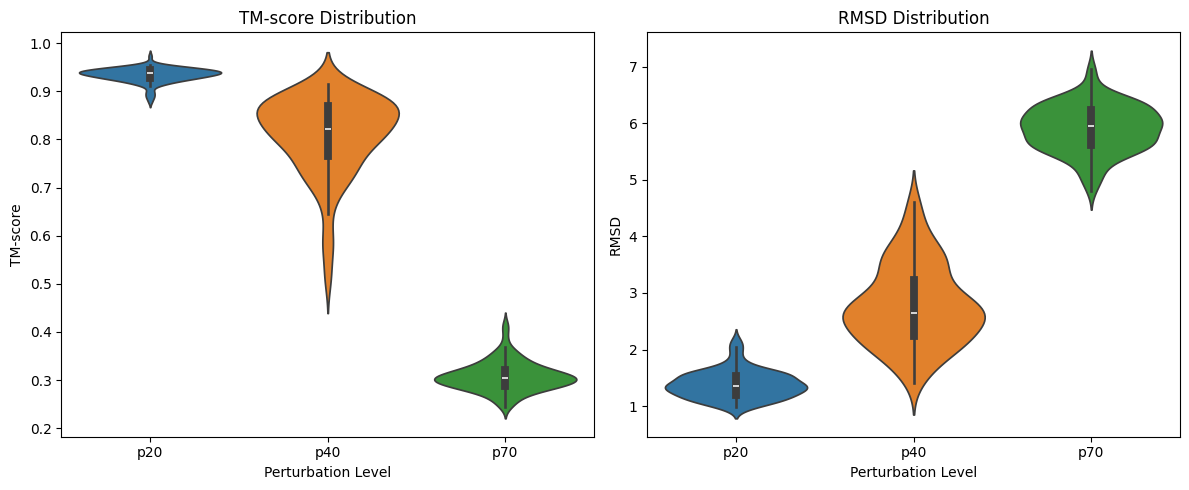

In [7]:
perturbation_levels = ["p20", "p40", "p70"]

boltz_dir = output_dir
esmfold_dir = Path(
    "/Users/thomasbush/Downloads/perturbation_outputs/outputs/n/holylfs06/LABS/"
    "bsabatini_lab/Everyone/tbush/protein_rsa/multi_mut/augmented/outputs"
)

dfs = []
for level in perturbation_levels:
    b = pd.read_csv(boltz_dir / level / "structure_scores.csv")
    b["perturbation"], b["model"] = level, "boltz"
    dfs.append(b)

    e = pd.read_csv(esmfold_dir / level / "esmfold_structure_scores.csv")
    e["perturbation"], e["model"] = level, "esmfold"
    dfs.append(e)

all_scores = pd.concat(dfs, ignore_index=True)
print(all_scores.groupby(["model", "perturbation"]).size())

model_palette = {"boltz": "#1f77b4", "esmfold": "#d62728"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, metric, title in [
    (axes[0], "tm_score", "TM-score Distribution"),
    (axes[1], "rmsd", "RMSD Distribution"),
]:
    sns.violinplot(
        x="perturbation",
        y=metric,
        hue="model",
        data=all_scores,
        inner="box",
        palette=model_palette,
        order=perturbation_levels,
        ax=ax,
    )
    ax.set_xlabel("Perturbation Level")
    ax.set_ylabel(metric)
    ax.set_title(title)
axes[0].get_legend().remove()
plt.tight_layout()
plt.show()

## Exploring hidden representations 

In [25]:
import torch
hidden_reps_path = Path('/Users/thomasbush/Downloads/seq_00318/hidden_reps.pt')
hidden_reps = torch.load(hidden_reps_path)

original_hidden_reps_path = Path("/Users/thomasbush/Downloads/hidden_reps/original/hidden_reps.pt")
original_hidden_reps = torch.load(original_hidden_reps_path)

In [13]:
model_outputs = torch.load("/Users/thomasbush/Downloads/seq_00318/model_outputs.pt")

In [26]:
original_hidden_reps["step_0"].keys()

dict_keys(['input_embedder', 'pairformer_0_layer_s', 'pairformer_1_layer_s', 'pairformer_2_layer_s', 'pairformer_3_layer_s', 'pairformer_4_layer_s', 'pairformer_5_layer_s', 'pairformer_6_layer_s', 'pairformer_7_layer_s', 'pairformer_8_layer_s', 'pairformer_9_layer_s', 'pairformer_10_layer_s', 'pairformer_11_layer_s', 'pairformer_12_layer_s', 'pairformer_13_layer_s', 'pairformer_14_layer_s', 'pairformer_15_layer_s', 'pairformer_16_layer_s', 'pairformer_17_layer_s', 'pairformer_18_layer_s', 'pairformer_19_layer_s', 'pairformer_20_layer_s', 'pairformer_21_layer_s', 'pairformer_22_layer_s', 'pairformer_23_layer_s', 'pairformer_24_layer_s', 'pairformer_25_layer_s', 'pairformer_26_layer_s', 'pairformer_27_layer_s', 'pairformer_28_layer_s', 'pairformer_29_layer_s', 'pairformer_30_layer_s', 'pairformer_31_layer_s', 'pairformer_32_layer_s', 'pairformer_33_layer_s', 'pairformer_34_layer_s', 'pairformer_35_layer_s', 'pairformer_36_layer_s', 'pairformer_37_layer_s', 'pairformer_38_layer_s', 'pairf

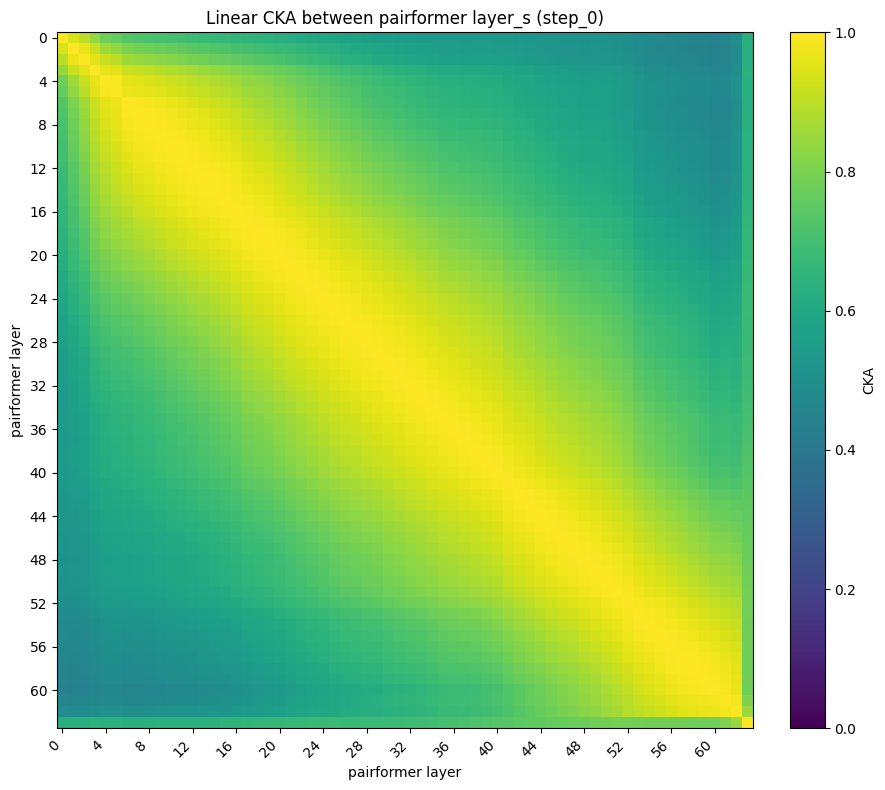

In [ ]:
import re

from protein_interpretability.rsa.metrics import linear_cka

step0 = hidden_reps["step_10"]
pat = re.compile(r"^pairformer_(\d+)_layer_s$")
layer_keys = []
for k in step0:
    m = pat.match(k)
    if m:
        layer_keys.append((int(m.group(1)), k))
layer_keys = [k for _, k in sorted(layer_keys)]
# Per-layer single track: (N, 384); CKA needs matching rows (same tokens)
Xs = [step0[k].squeeze(0) for k in layer_keys]
L = len(Xs)
device, dtype = Xs[0].device, Xs[0].dtype
cka_mat = torch.empty(L, L, device=device, dtype=dtype)
for i in range(L):
    for j in range(L):
        cka_mat[i, j] = linear_cka(Xs[i], Xs[j])

labels = [pat.match(k).group(1) for k in layer_keys]

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cka_mat.cpu().numpy(), vmin=0, vmax=1, cmap="viridis")
ax.set_title("Linear CKA between pairformer layer_s (step_0)")
ax.set_xlabel("pairformer layer")
ax.set_ylabel("pairformer layer")
tick = max(1, L // 16)
ax.set_xticks(range(0, L, tick))
ax.set_xticklabels(labels[::tick], rotation=45, ha="right")
ax.set_yticks(range(0, L, tick))
ax.set_yticklabels(labels[::tick])
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="CKA")
plt.tight_layout()
plt.show()

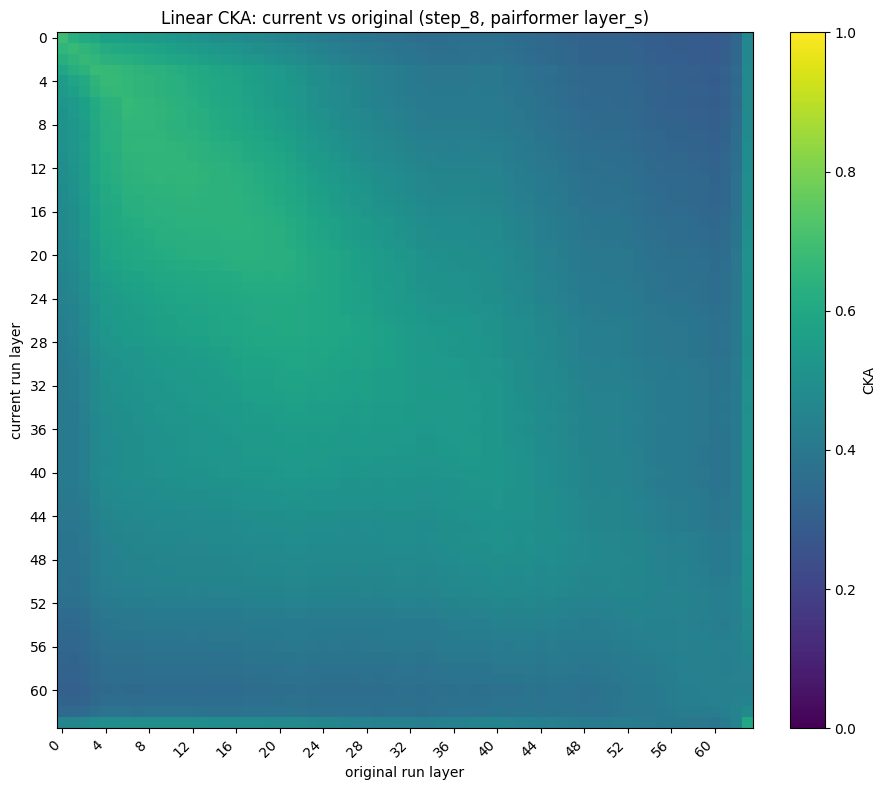

In [32]:
import re

from protein_interpretability.rsa.metrics import linear_cka

# Same recycling step: `hidden_reps` (current) vs `original_hidden_reps` (reference)
step_key = "step_8"
pat = re.compile(r"^pairformer_(\d+)_layer_s$")


def _layer_s_by_index(step_dict):
    m = {}
    for k in step_dict:
        mo = pat.match(k)
        if mo:
            m[int(mo.group(1))] = step_dict[k].squeeze(0)
    return m


step_cur = hidden_reps[step_key]
step_orig = original_hidden_reps[step_key]
by_cur = _layer_s_by_index(step_cur)
by_orig = _layer_s_by_index(step_orig)
layer_ids = sorted(set(by_cur) & set(by_orig))
if not layer_ids:
    raise ValueError("No overlapping pairformer_*_layer_s layer indices between runs.")

Xa = [by_cur[i] for i in layer_ids]
Xb = [by_orig[i] for i in layer_ids]
assert Xa[0].shape[0] == Xb[0].shape[0], "Token counts differ; CKA needs same N."

L = len(layer_ids)
device, dtype = Xa[0].device, Xa[0].dtype
cka_cross = torch.empty(L, L, device=device, dtype=dtype)
for i in range(L):
    for j in range(L):
        cka_cross[i, j] = linear_cka(Xa[i], Xb[j])

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cka_cross.cpu().numpy(), vmin=0, vmax=1, cmap="viridis")
ax.set_title(f"Linear CKA: current vs original ({step_key}, pairformer layer_s)")
ax.set_ylabel("current run layer")
ax.set_xlabel("original run layer")
t = max(1, L // 16)
ax.set_yticks(range(0, L, t))
ax.set_yticklabels([str(layer_ids[i]) for i in range(0, L, t)])
ax.set_xticks(range(0, L, t))
ax.set_xticklabels([str(layer_ids[j]) for j in range(0, L, t)], rotation=45, ha="right")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="CKA")
plt.tight_layout()
plt.show()